# Netflix Data Analysis

## Project Objective

The objective of this project is to perform exploratory data analysis on the Netflix dataset and identify trends related to content type, countries, ratings, genres, directors, and audience preferences.

##  Import libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load dataset

> The notebook uses the Kaggle Netflix Titles dataset. When running outside Kaggle, update this path to the local dataset location.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Dataset Understanding

In [3]:
df.shape

(8807, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.dtypes


In [6]:
df.isna().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration         True
listed_in       False
description     False
dtype: bool

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8802    False
8803    False
8804    False
8805    False
8806    False
Length: 8807, dtype: bool

## Data Cleaning

In [8]:
df.isnull().any()

show_id         False
type            False
title           False
director         True
cast             True
country          True
date_added       True
release_year    False
rating           True
duration         True
listed_in       False
description     False
dtype: bool

In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df.isnull().sum().idxmax()

'director'

In [ ]:
df["country"] = df["country"].fillna("Unknown")


In [ ]:
df["cast"] = df["cast"].fillna("Unknown")


In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed", errors="coerce")
df["date_added"].isna().sum()


In [ ]:
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])


In [ ]:
df.dropna(subset=["duration"]).shape


## Date Conversion and Time-Based Analysis

In [16]:
df["date_added"].dtype

dtype('<M8[ns]')

In [ ]:
df["date_added"].head()


In [18]:
df["date_added"].dtype

dtype('<M8[ns]')

In [19]:
df["date_added"].dt.year

0       2021.0
1       2021.0
2       2021.0
3       2021.0
4       2021.0
         ...  
8802    2019.0
8803    2019.0
8804    2019.0
8805    2020.0
8806    2019.0
Name: date_added, Length: 8807, dtype: float64

In [20]:
df["date_added"].dt.month

0        9.0
1        9.0
2        9.0
3        9.0
4        9.0
        ... 
8802    11.0
8803     7.0
8804    11.0
8805     1.0
8806     3.0
Name: date_added, Length: 8807, dtype: float64

In [21]:
df["date_added"].dt.year.value_counts()


date_added
2019.0    1999
2020.0    1878
2018.0    1625
2021.0    1498
2017.0    1164
2016.0     418
2015.0      73
2014.0      23
2011.0      13
2013.0      10
2012.0       3
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64

In [22]:
df["date_added"].dt.year.value_counts().idxmax()

np.float64(2019.0)

In [23]:
df.groupby(["date_added","type"]).size().unstack(fill_value=0)

type,Movie,TV Show
date_added,,
2008-01-01,1,0
2008-02-04,0,1
2009-05-05,1,0
2009-11-18,1,0
2010-11-01,1,0
...,...,...
2021-09-21,4,1
2021-09-22,3,6
2021-09-23,1,1


### Observations

The `date_added` column was converted from object datatype into datetime format to enable time-based analysis. Additional features such as year and month were extracted from the date column. This helped identify yearly content addition trends and understand Netflix's expansion pattern over time.


## Exploratory Data Analysis

In [ ]:
df["type"].value_counts()


In [ ]:
df["type"].value_counts(normalize=True).mul(100).round(2)


Movies represent 69.62% of the titles in this dataset, compared with 30.38% for TV Shows. This describes the catalog composition in the dataset; it does not by itself establish Netflix's investment strategy.


In [ ]:
content_type = df["type"].value_counts()
content_type.plot(kind="bar")
plt.title("Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()


### Insight

The graph shows that Movies are significantly higher in number compared to TV Shows on Netflix. This indicates that Netflix focuses more on movie content than TV Shows. However, TV Shows also represent an important portion of the platform’s content library.

## Country Analysis

In [ ]:
countries = df["country"].dropna().str.split(",").explode().str.strip()
top_10_country = countries.value_counts().head(10)
print(top_10_country)


In [ ]:
countries.value_counts().head(10)


In [ ]:
top_10_country.plot(kind="barh")
plt.title("Top 10 Countries Represented in Netflix Content")
plt.xlabel("Content Count")
plt.ylabel("Country")
plt.show()


### Insight

The Top 10 countries account for a large share of the Netflix catalog, indicating a strong concentration of content production. The United States dominates the platform, while a few other countries contribute substantially. This pattern suggests that Netflix's content acquisition and production strategy is centered around major entertainment markets.

## Year-wise Content Trend Analysis

In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"], format="mixed", errors="coerce")
df["year"]=df["date_added"].dt.year
year_count=df["year"].value_counts()
high_content_addition=year_count.idxmax()
print(high_content_addition)

In [31]:
yearly_content = df["year"].value_counts().sort_index()
print(yearly_content)

year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


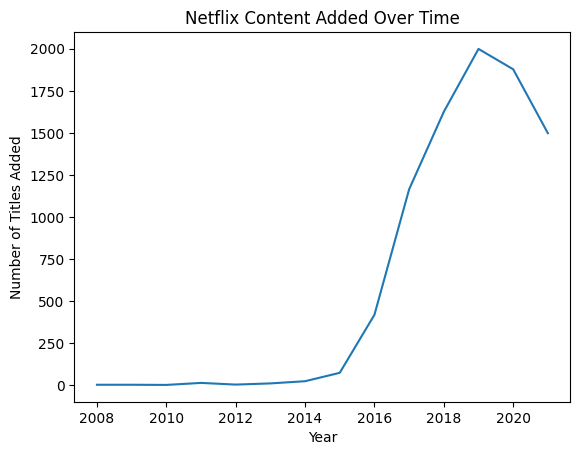

In [32]:
yearly_content.plot(kind="line")
plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

### Insight

The line graph shows that Netflix experienced rapid growth after 2015. Content additions increased significantly during the following years, indicating aggressive expansion of the platform's content library.

## Ratings Analysis

In [ ]:
most_rating = df["rating"].value_counts().idxmax()
print(most_rating)


### Insight

TV-MA is the most common rating in this dataset. This indicates that mature-audience titles make up a substantial portion of the catalog, but the dataset alone does not establish Netflix's overall audience-targeting strategy.


The most common rating in this dataset is TV-MA.


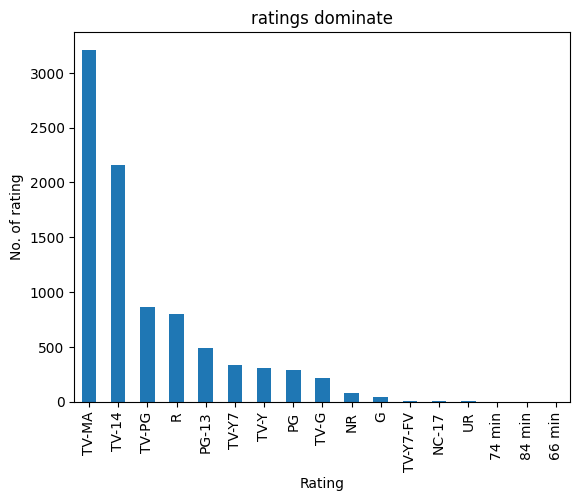

In [34]:
most_rating=df["rating"].value_counts()
most_rating.plot(kind="bar")
plt.title("ratings dominate")
plt.xlabel("Rating")
plt.ylabel("No. of rating")
plt.show()

### Insight

TV-MA is the most common rating in the dataset, so mature-audience content represents a substantial portion of the catalog.


## Director Analysis

In [ ]:
directors = df["director"].dropna().str.split(",").explode().str.strip()
most_common_director = directors.value_counts().idxmax()
print(most_common_director)


### Observation

Multiple directors are present in some rows of the dataset. Directors are separated by commas, so the column must be split and expanded before performing accurate director frequency analysis.

In [ ]:
top_director = directors.value_counts().head(10)
print(top_director)


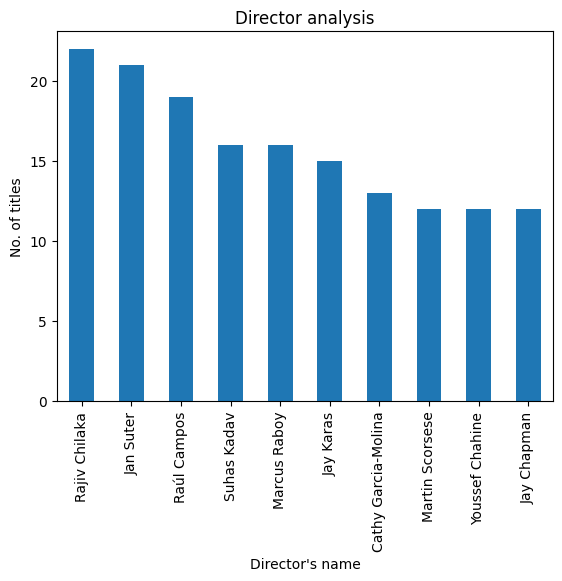

In [37]:
top_director.plot(kind="bar")
plt.title("Director analysis")
plt.xlabel("Director's name")
plt.ylabel("No. of titles")
plt.show()

### Insight

The director analysis counts individual director names after splitting multi-director entries. The resulting frequency distribution shows which directors have the most titles represented in the dataset.


## Cast Analysis

In [ ]:
actors = df["cast"].dropna().str.split(",").explode().str.strip()
most_common_actor = actors.value_counts().idxmax()
print(most_common_actor)


### Observation

The cast column can contain multiple actors in a single row. The analysis therefore splits and explodes the field before calculating actor frequencies.


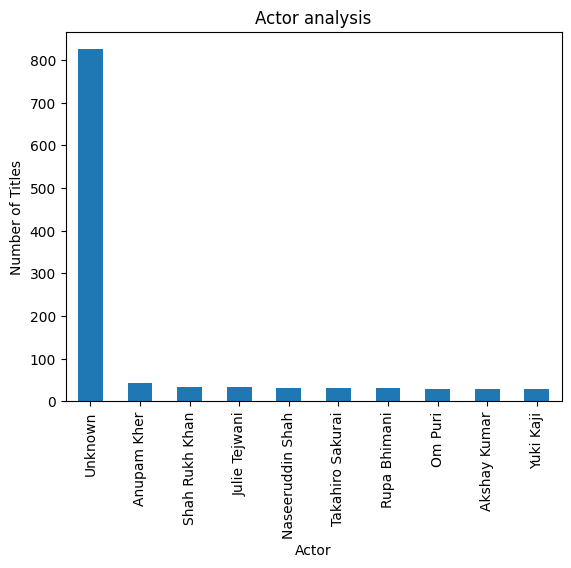

In [39]:
actors=df["cast"].dropna()
actors=actors.str.split(",")
actors=actors.explode()
actors=actors.str.strip()
top_actor=actors.value_counts().head(10)

top_actor.plot(kind="bar")
plt.title("Actor analysis")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")
plt.show()

## Genre Analysis

In [ ]:
genres = df["listed_in"].dropna().str.split(",").explode().str.strip()
most_common_genre = genres.value_counts().idxmax()
print(most_common_genre)


In [41]:
genre_df = df[['year', 'listed_in']].copy()
genre_df['listed_in'] = genre_df['listed_in'].str.split(',')
genre_df = genre_df.explode('listed_in')
genre_df['listed_in'] = genre_df['listed_in'].str.strip()
genre_growth = genre_df.groupby(['year', 'listed_in']).size().reset_index(name='count')
genre_growth.head(100)

,year,listed_in,count
0,2008.0,Dramas,1
1,2008.0,Independent Movies,1
2,2008.0,Stand-Up Comedy & Talk Shows,1
3,2008.0,Thrillers,1
4,2009.0,Dramas,1
...,...,...,...
95,2016.0,LGBTQ Movies,2
96,2016.0,Movies,12
97,2016.0,Music & Musicals,13
98,2016.0,Reality TV,5


### Insight

The genre analysis counts individual genre labels after splitting multi-genre entries. This provides a more meaningful frequency comparison than treating combinations of genres as single categories.


In [ ]:
top_genre = genres.value_counts().head(10)

top_genre.plot(kind="bar")
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.show()


### Insight

International Movies, Dramas, and Comedies are among the most frequently represented genre labels in the dataset. This describes catalog composition rather than viewer popularity or engagement.


## Duration Analysis

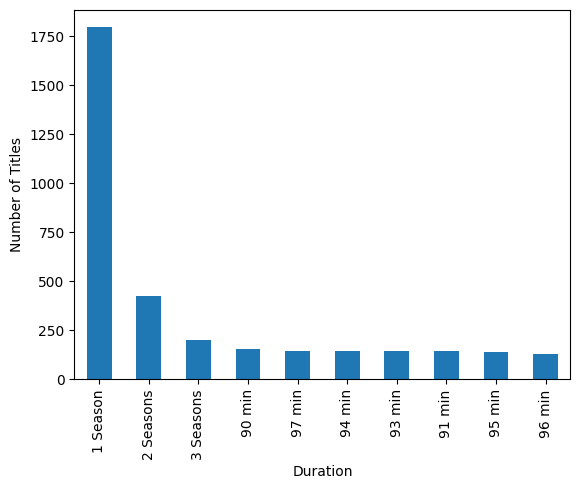

In [43]:
duration=df["duration"].dropna()

top_duration=duration.value_counts().head(10)
top_duration.plot(kind="bar")
plt.xlabel("Duration")
plt.ylabel("Number of Titles")
plt.show()


### Insight

The most frequent duration labels in the dataset include 1 Season, 2 Seasons, 3 Seasons, and 90-minute movies. These are catalog-frequency observations and should not be interpreted as evidence of audience preference.


## Business Insights

### 1. How is the catalog distributed between Movies and TV Shows?

Movies account for 69.62% of titles in the dataset, while TV Shows account for 30.38%.

### 2. Which countries are most represented?

After splitting multi-country entries, the United States is the most frequently represented country, followed by India and other major content-producing markets.

### 3. How did content additions change over time?

The yearly `date_added` analysis shows that the number of titles added varied substantially across years, with the strongest concentration in the later years represented in the dataset.

### 4. What ratings are most common?

TV-MA is the most common rating in the dataset. This means mature-audience titles form a substantial portion of the catalog; it does not, by itself, prove Netflix's overall audience-targeting strategy.

### 5. Which genres are most represented?

International Movies, Dramas, and Comedies are among the most frequently represented individual genre labels after multi-genre entries are split.


## Conclusion

### What this analysis shows

- Movies represent a larger share of the catalog than TV Shows in this dataset.
- Country representation is concentrated among several major markets, with the United States appearing most frequently after multi-country entries are split.
- Content additions vary by year, with substantial activity in the later years represented in the dataset.
- TV-MA is the most common rating.
- International Movies, Dramas, and Comedies are among the most frequently represented genre labels.
- Duration analysis shows common catalog labels such as 1 Season, 2 Seasons, 3 Seasons, and 90-minute movies.

### Analytical limitation

This is an exploratory analysis of catalog metadata. The dataset can describe content composition and historical addition patterns, but it cannot by itself establish Netflix's investment decisions, audience preferences, causal relationships, or viewer engagement.
